In [112]:
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.config import np, plt, sp
import src.simulations as sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
a, p = sp.symbols('a p') # arrival and access probabilities symbols

P = sp.Matrix([
    [(1-a)**2,    a*(1-a),          a*(1-a),          a**2              ],
    [p*(1-a)**2,  (1-a)*(1-p+p*a),  p*a*(1-a),        a*(1-p+p*a)       ],
    [p*(1-a)**2,  p*a*(1-a),        (1-a)*(1-p+p*a),  a*(1-p+p*a)       ],
    [0,           p*(1-a)*(1-p),    p*(1-p)*(1-a),    p**2 + (1-p)*(1-p+2*p*a) ]
])

pi00s, pi01s, pi10s, pi11s = sp.symbols('pi00 pi01 pi10 pi11')
pi = sp.Matrix([pi00s, pi01s, pi10s, pi11s])

# equações: pi = pi P  e soma(pi)=1
eqs = list((pi.T * P - pi.T)[0,:])
eqs[-1] = pi00s + pi01s + pi10s + pi11s - 1
sol = sp.solve(eqs, [pi00s, pi01s, pi10s, pi11s], dict=True)
sol = sol[0]  # dicionário com pi00,pi01,pi10,pi11
pi00, pi01, pi10, pi11 = [sol[pi00s], sol[pi01s], sol[pi10s], sol[pi11s]]

# Throughput

In [127]:
throughput_expr = sp.simplify(pi01*p + pi10*p + 2*pi11*p*(1-p))
throughput_data = simulate_metric(sim.throughput, time=20000, method="numpy")
np.save("data/throughput_data.npy", throughput_data)

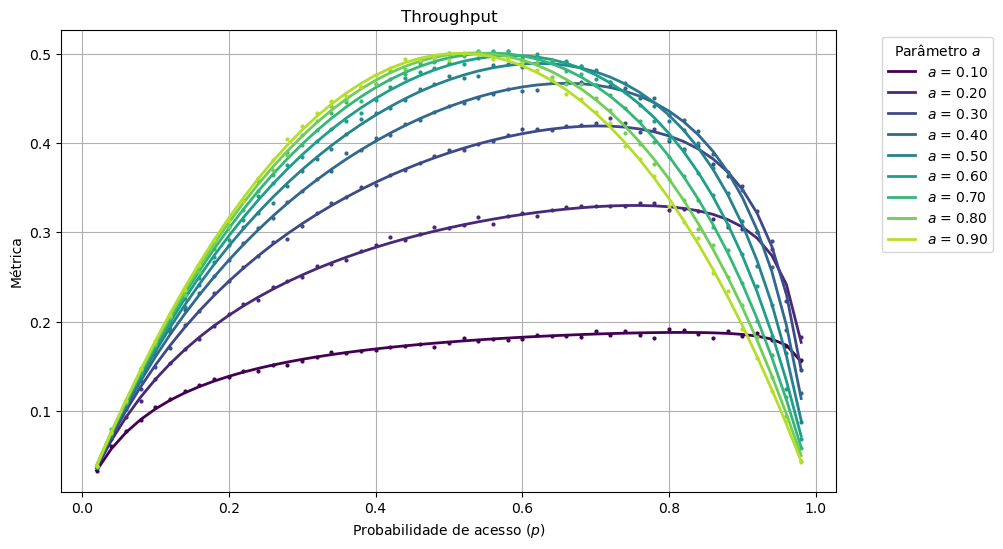

In [131]:
compare_metric_plot(
    analytical_expr=throughput_expr,
    simulation_data=throughput_data,
    title="Throughput",
    cmap="viridis",
    axis="p"
)

# Validação da Lei de Little: L_up = W_up * thr*/n
sendo L_up a probabilidade de ocupação do update_pack, W_up o delay do update_pack, thr o throughtput total do sistema e n o número de nós

In [37]:
throughput_expr_func = make_metric_func(throughput_expr)
def mean_delay_up_pack_oc(arrival_prob, send_prob, time):
    # esta simulação prova que W_up = thr/2 * L_up
    # thr de 1 nó: metade do thr do sistema. por isso o fator 2
    return 2 * sim.occupation_up_pack(arrival_prob, send_prob, time) / throughput_expr_func(arrival_prob, send_prob)

In [38]:
mean_delay_up_pack_data = simulate_metric(sim.mean_delay_up_pack, time=100000, method="numpy")
np.save("data/mean_delay_up_pack_data.npy", mean_delay_up_pack_data)

KeyboardInterrupt: 

In [54]:
mean_delay_up_pack_oc_data = simulate_metric(mean_delay_up_pack_oc, time=200000, method="numpy")

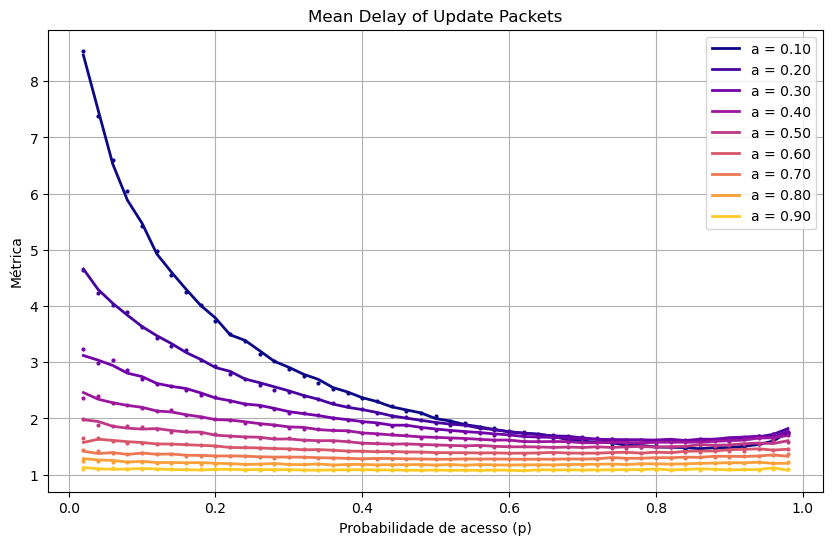

In [ ]:
plot_metric(
    analytical_func = make_metric_func(mean_delay_up_pack_oc_data),
    simulation_data_func = make_metric_func(mean_delay_up_pack_data),
    title = "Mean Delay of Update Packets",
    cmap = "plasma",
    axis = "p"
)

# PAoI
para 2 nós, PAoI = W_up + 2/thr

In [96]:
AAoI_sim_data, PAoI_sim_data = simulate_metric(sim.AAoI_PAoI_sim, time=400000, method="numpy")
np.save("data/AAoI_sim_data.npy", AAoI_sim_data)
np.save("data/PAoI_sim_data.npy", PAoI_sim_data)

In [ ]:
# auto complete age expression
W_up_sim_func = make_metric_func(mean_delay_up_pack_data)
PAoI_W_up = np.vectorize(lambda a, p: W_up_sim_func(a, p) + 2/throughput_expr_func(a, p))   

In [97]:
AAoI_sim_data = np.load("data/AAoI_sim_data.npy")
PAoI_sim_data = np.load("data/PAoI_sim_data.npy")
PAoI_sim_func = make_metric_func(PAoI_sim_data)

In [59]:
AAoI_temp_sim_data = np.load("data/AAoI_sim_data.npy")
AAoI_temp_sim_func = make_metric_func(AAoI_temp_sim_data.T)
plot_metric(
    analytical_func = PAoI_W_up,
    simulation_data_func = PAoI_sim_func,
    title="PAoI($p$) para vários valores de $a$",
    cmap="winter",
    axis="p",
    yrange=(4, 20)
)

TypeError: 'Mul' object is not callable

<Figure size 1000x600 with 0 Axes>

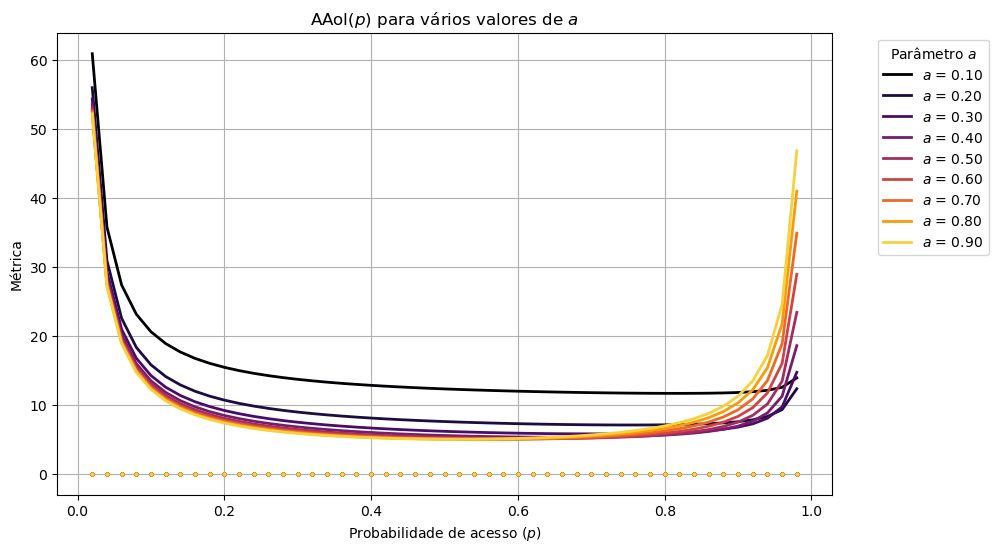

In [ ]:
AAoI_expr = sp.simplify( 2 / throughput_expr + 1 )
compare_metric_plot(
    analytical_expr=AAoI_expr,
    simulation_data=AAoI_sim_data,
    title="AAoI($p$) para vários valores de $a$",
    cmap="inferno",
    axis="p",
    yrange = (4, 20)
)

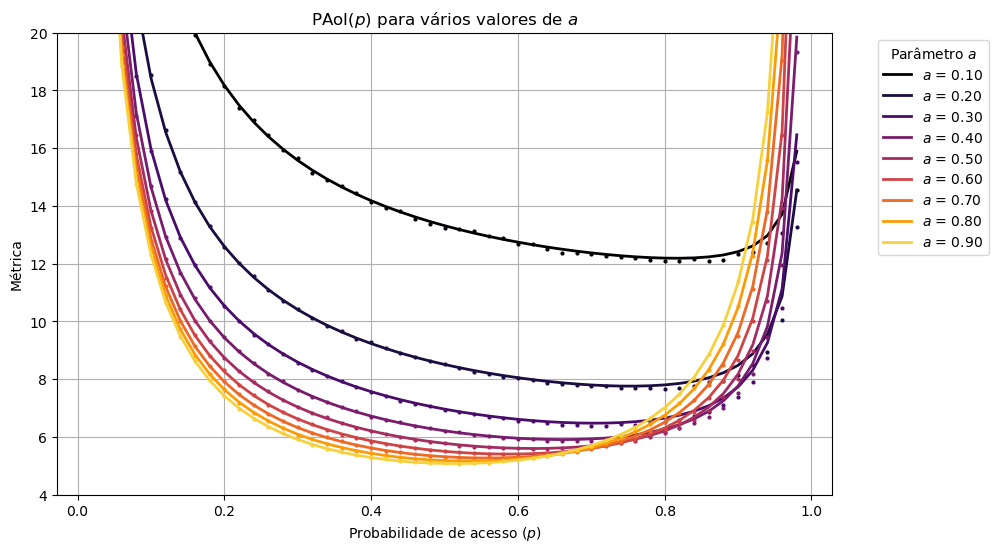

In [99]:
PAoI_expr = sp.simplify( (L_up_expr + 1) * (2 / throughput_expr))
compare_metric_plot(
    analytical_expr=PAoI_expr,
    simulation_data=PAoI_sim_data,
    title="PAoI($p$) para vários valores de $a$",
    cmap="inferno",
    axis="p",
    yrange=(4, 20)
)

# Hipótese de relação entre L_up e thr

In [29]:
L_tot = pi01 + pi11
thr = throughput_expr/2  # throughput de 1 nó
taxa_desc = pi01 * a * (1 - p) + pi11 * a * (1 - p + p**2)
L_up_expr = sp.simplify(L_tot*( thr / (thr + taxa_desc) ))

In [80]:
L_up_sim_data = simulate_metric(sim.occupation_up_pack, time=200000, method="numpy")
np.save("data/L_up_sim_data.npy", L_up_sim_data)

In [9]:
L_up_sim_data = np.load("data/L_up_sim_data.npy")

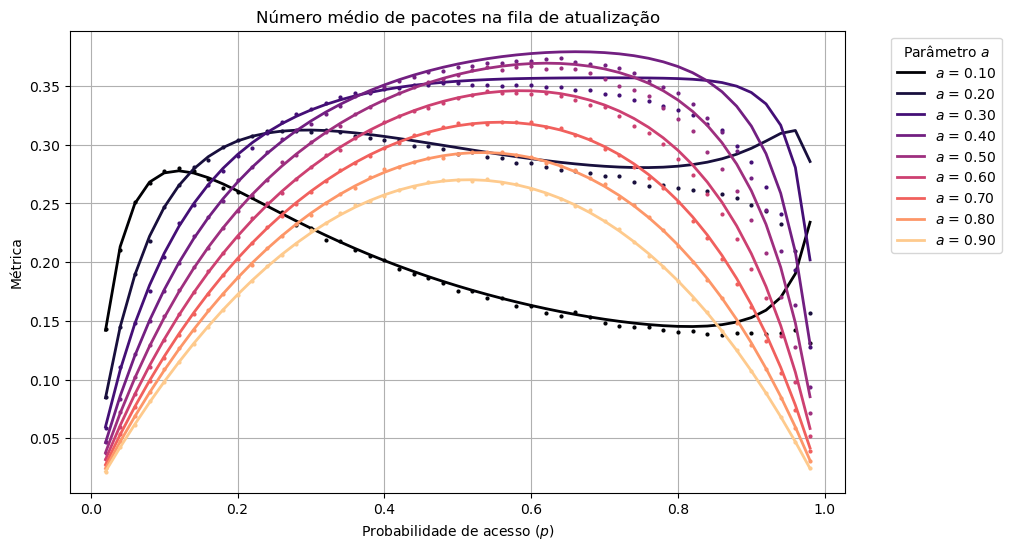

In [47]:
compare_metric_plot(
    analytical_expr=L_up_expr,
    simulation_data=L_up_sim_data,
    title="Número médio de pacotes na fila de atualização",
    cmap="magma",
    axis="p"
)

In [6]:
sp.factor(-(p-0.5)**(2)+0.25)

-1.0*p*(1.0*p - 1.0)